# Simulation Survey: Recreating Gaikwad et al. (PRL 132, 200401, 2024)
### *Non-Markovian to Markovian Transition in Open Quantum System Dynamics*

This notebook surveys the tools and techniques for **numerically simulating** 
the four experiments in Gaikwad et al.

| Tool | Role |
|------|------|
| **QuTiP 5** `mesolve` | Primary Lindblad master equation solver |
| **QuTiP 5** `mcsolve` | Monte Carlo quantum trajectory solver |
| **QuTiP 5** `brmesolve` | Bloch-Redfield solver (structured bath) |
| **PennyLane** | Circuit-based Bell state prep; noise channels |
| **SciPy / NumPy** | ODE integration, signal processing, fitting |

---
**Paper in one sentence:** Q and A are entangled in a Bell state. Q couples 
to E (small quantum environment). As dephasing gamma on E is tuned, the system 
transitions from non-Markovian (concurrence revivals, N>0) to Markovian 
(exponential decay, N=0), and at high gamma the Zeno effect protects Q-A entanglement.

---
## 1. Imports and Physical Parameters

All times in **us**, all frequencies in **rad/us** (angular).
The paper quotes Omega/2pi in MHz so we multiply by 2*pi throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import trapezoid
import warnings; warnings.filterwarnings('ignore')

import qutip as qt
print(f'QuTiP    {qt.__version__}')

import pennylane as qml
print(f'PennyLane {qml.__version__}')

import scipy
print(f'NumPy  {np.__version__}   SciPy  {scipy.__version__}')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

QuTiP    5.2.3
PennyLane 0.44.1
NumPy  2.4.3   SciPy  1.17.1


In [4]:
# ================================================================
#  Physical parameters from Gaikwad et al. Table I and text
# ================================================================

# Coherence times (us)
T2Q = 39.0          # Qubit    T2*
T2A = 41.0          # Ancilla  T2*

# Coupling rates (rad/us) -- 2pi * value_in_MHz
Om_QA = 2*np.pi * 0.477   # Q-A iSWAP coupling (2pi x 0.477 MHz)
Om_QE = 2*np.pi * 0.473   # Q-E iSWAP coupling (2pi x 0.473 MHz)

# E-resonator dispersive coupling
chi = 2*np.pi * 0.200     # chi/2pi = 200 kHz -> rad/us

# Empirical dephasing calibration: gamma = 1.84 * A_in^1.5  (us^-1)
gamma_calib = lambda A_in: 1.84 * A_in**1.5

# Natural decay rate of Q-A concurrence (no E coupling)
Gamma0 = 1/T2Q + 1/T2A

# Time axis for simulations (us)
tlist = np.linspace(0, 10, 400)

print(f'Gamma0 = 1/T2Q + 1/T2A = {Gamma0:.5f} us^-1')
print(f'Om_QA  = {Om_QA:.4f} rad/us')
print(f'Om_QE  = {Om_QE:.4f} rad/us')
print(f'chi    = {chi:.4f}   rad/us')
print(f'iSWAP period: 2pi/Om_QE = {2*np.pi/Om_QE:.3f} us')

Gamma0 = 1/T2Q + 1/T2A = 0.05003 us^-1
Om_QA  = 2.9971 rad/us
Om_QE  = 2.9719 rad/us
chi    = 1.2566   rad/us
iSWAP period: 2pi/Om_QE = 2.114 us


---
## 2. Operator Algebra -- Building the Hilbert Space

The 3-qubit Hilbert space is H = H_Q x H_A x H_E, dimension 2^3 = 8.

### How `qt.tensor` works

`qt.tensor(A, B, C)` computes A x B x C using the Kronecker product.
To embed an operator acting on qubit i, tensor it with identity on all others.

**Qubit index convention:** 0 = Q, 1 = A, 2 = E

In [5]:
# Single-qubit Pauli building blocks
I  = qt.qeye(2)
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()
sp = qt.sigmap()   # sigma_+  raising operator
sm = qt.sigmam()   # sigma_-  lowering operator

# Embed operator into 3-qubit space
# Qubit order: 0=Q, 1=A, 2=E
def Q(op):   return qt.tensor(op, I,  I )
def A(op):   return qt.tensor(I,  op, I )
def Env(op): return qt.tensor(I,  I,  op)

print('Q(sz) acts on 3-qubit space, dims:', Q(sz).dims)
print('A(sp) dims:', A(sp).dims)

# Show how tensor product embeds operators
print('\nsz x I (4x4):'); print(qt.tensor(sz, I))
print('\nsp x sm  (exchange coupling term):'); print(qt.tensor(sp, sm))

Q(sz) acts on 3-qubit space, dims: [[2, 2, 2], [2, 2, 2]]
A(sp) dims: [[2, 2, 2], [2, 2, 2]]

sz x I (4x4):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]

sp x sm  (exchange coupling term):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
# Bell states (QuTiP labelling)
# '00' = Phi+ = (|00> + |11>)/sqrt(2)
# '01' = Phi- = (|00> - |11>)/sqrt(2)
# '10' = Psi+ = (|10> + |01>)/sqrt(2)  <-- paper uses this
# '11' = Psi- = (|10> - |01>)/sqrt(2)

Phi_plus = qt.bell_state('00')
Psi_plus = qt.bell_state('10')   # paper: Q up, A down superposition

print('Psi+ =', Psi_plus.trans())
print(f'Concurrence of |Psi+>: {qt.concurrence(qt.ket2dm(Psi_plus)):.6f}')

# Initial 3-qubit state: Q-A in Bell state, E in ground state |0>
e_ground = qt.basis(2, 0)
psi0_3q  = qt.tensor(Psi_plus, e_ground)
rho0_3q  = qt.ket2dm(psi0_3q)

print(f'\nrho0_3q dims: {rho0_3q.dims}')
print(f'Tr(rho0)  = {rho0_3q.tr():.6f}  (must be 1)')
print(f'Tr(rho0^2) = {(rho0_3q**2).tr():.6f} (1 = pure state)')

# Verify Q-A partial trace recovers the Bell state
rho_QA_init = rho0_3q.ptrace([0, 1])
print(f'C(rho_QA at t=0) = {qt.concurrence(rho_QA_init):.6f}')

Psi+ = Quantum object: dims=[[1], [2, 2]], shape=(1, 4), type='bra', dtype=Dense
Qobj data =
[[0.         0.70710678 0.70710678 0.        ]]
Concurrence of |Psi+>: 1.000000

rho0_3q dims: [[2, 2, 2], [2, 2, 2]]
Tr(rho0)  = 1.000000  (must be 1)
Tr(rho0^2) = 1.000000 (1 = pure state)
C(rho_QA at t=0) = 1.000000


---
## 3. Building the Hamiltonians

From the paper Eqs. (1)-(3):

$$H_{tot} = H_S + H_E + H_{SE}$$

$$H_{Q,E} = \hbar\Omega_{Q,E}(\sigma_+^Q \sigma_-^E + \sigma_-^Q \sigma_+^E)$$

$$H_{int} = \chi\, a^\dagger a\, \sigma_z^E, \quad \chi/2\pi = 200\,\text{kHz}$$

We work in units where hbar=1, so Omega has units rad/us.

H_QE eigenvalues (rad/us):
[-4.2208 -4.2208  0.      0.      0.      0.      4.2208  4.2208]

H_QE coupling strength:  2.9719 rad/us  =  0.4730 MHz
H_QA coupling strength:  2.9971 rad/us  =  0.4770 MHz


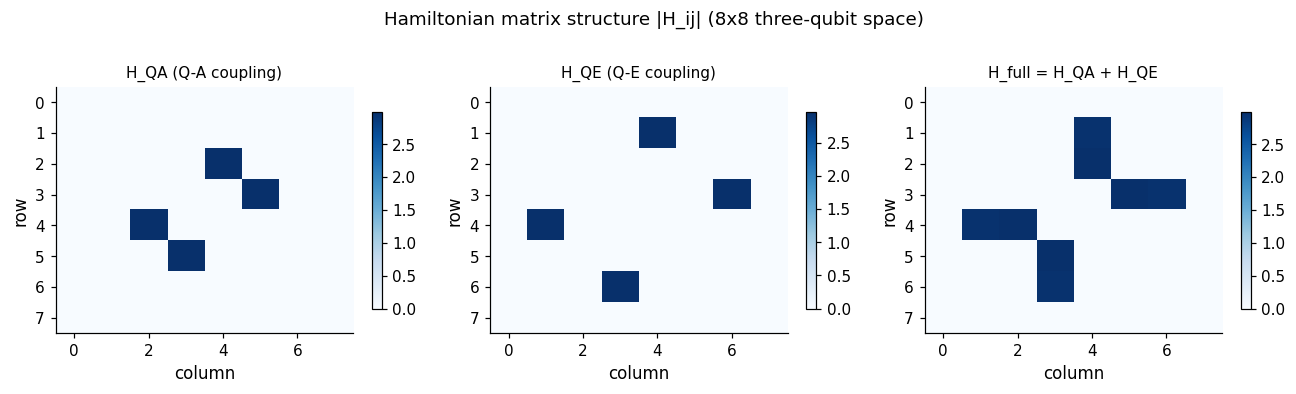

In [7]:
# Q-A iSWAP-type coupling
H_QA = Om_QA * (qt.tensor(sp, sm, I) + qt.tensor(sm, sp, I))

# Q-E iSWAP-type coupling (only active when Q-E interaction enabled)
H_QE = Om_QE * (qt.tensor(sp, I, sm) + qt.tensor(sm, I, sp))

# Full Hamiltonian
H_full = H_QA + H_QE

print('H_QE eigenvalues (rad/us):')
print(np.round(H_full.eigenenergies(), 4))

print(f'\nH_QE coupling strength:  {Om_QE:.4f} rad/us  =  {Om_QE/(2*np.pi):.4f} MHz')
print(f'H_QA coupling strength:  {Om_QA:.4f} rad/us  =  {Om_QA/(2*np.pi):.4f} MHz')

# Visualise Hamiltonian matrix structure
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
titles = ['H_QA (Q-A coupling)', 'H_QE (Q-E coupling)', 'H_full = H_QA + H_QE']
for ax, H, title in zip(axes, [H_QA, H_QE, H_full], titles):
    im = ax.imshow(np.abs(H.full()), cmap='Blues', aspect='auto')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('column'); ax.set_ylabel('row')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Hamiltonian matrix structure |H_ij| (8x8 three-qubit space)', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Lindblad Collapse Operators

The GKSL master equation:

$$\frac{d\rho}{dt} = -\frac{i}{\hbar}[H,\rho] + \sum_k \gamma_k\left(L_k\rho L_k^\dagger - \frac{1}{2}\{L_k^\dagger L_k,\rho\}\right)$$

### Pure dephasing: $L = \sqrt{\gamma_\phi}\,\sigma_z$

For transmon qubits at the flux sweet spot, the dominant decoherence channel is
**pure dephasing** (no energy relaxation). The sigma_z jump operator:
- Leaves populations unchanged: rho_00, rho_11 constant
- Decays coherences: rho_01(t) = rho_01(0) * exp(-gamma * t)

For a dephasing time T2*, the collapse operator is L = sqrt(1/T2*) * sigmaz.

**Key point for Exp.3:** Adding `sqrt(gamma_E) * sigmaz^E` as a collapse operator
on E is *exactly* what the thermal photons do -- each photon traversing E's resonator
fires a quantum jump that collapses E to a definite eigenstate.

c_Q = sqrt(1/T2Q) * sz_Q  (diagonal of 8x8 matrix):
[ 0.16013  0.16013  0.16013  0.16013 -0.16013 -0.16013 -0.16013 -0.16013]

Dephasing rate on Q: gamma_Q = 1/T2Q = 0.02564 us^-1
Dephasing rate on A: gamma_A = 1/T2A = 0.02439 us^-1


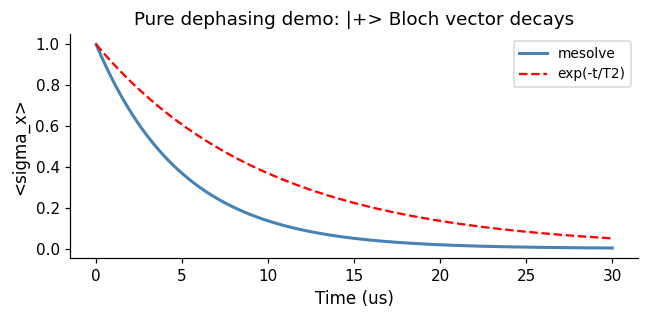

In [8]:
def build_c_ops(gamma_E=0.0):
    """
    Build Lindblad collapse operators for the 3-qubit Q-A-E system.

    Parameters
    ----------
    gamma_E : float
        Dephasing rate on environment qubit E (rad/us).
        0.0  --> non-Markovian (coherent E, no dephasing)
        ~1.0 --> onset of Markovian behaviour
        >>Om_QE --> Zeno regime

    Returns
    -------
    list of Qobj
        [c_Q, c_A] or [c_Q, c_A, c_E]
    """
    c_Q = np.sqrt(1.0/T2Q) * Q(sz)   # Q  pure dephasing
    c_A = np.sqrt(1.0/T2A) * A(sz)   # A  pure dephasing
    c_ops = [c_Q, c_A]
    if gamma_E > 0:
        c_E = np.sqrt(gamma_E) * Env(sz)   # E Lindblad dephasing
        c_ops.append(c_E)
    return c_ops

# Show the diagonal structure of the collapse operator
print('c_Q = sqrt(1/T2Q) * sz_Q  (diagonal of 8x8 matrix):')
print(np.round(np.diag(build_c_ops(0)[0].full()).real, 5))

print(f'\nDephasing rate on Q: gamma_Q = 1/T2Q = {1/T2Q:.5f} us^-1')
print(f'Dephasing rate on A: gamma_A = 1/T2A = {1/T2A:.5f} us^-1')

# Demonstrate pure dephasing on a single qubit: |+> state decoheres
rho_plus = qt.ket2dm((qt.basis(2,0) + qt.basis(2,1)).unit())
T2_demo  = 10.0
t_demo   = np.linspace(0, 30, 300)
res_demo = qt.mesolve(qt.qzero(2), rho_plus, t_demo,
                      [np.sqrt(1/T2_demo)*sz], [sx])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t_demo, res_demo.expect[0],          lw=2,  color='steelblue', label='mesolve')
ax.plot(t_demo, np.exp(-t_demo/T2_demo),     lw=1.5, color='red', ls='--', label='exp(-t/T2)')
ax.set(xlabel='Time (us)', ylabel='<sigma_x>',
       title='Pure dephasing demo: |+> Bloch vector decays')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. `qt.mesolve` -- The Master Equation Solver

```python
result = qt.mesolve(H, rho0, tlist, c_ops, e_ops, options={...})
```

| Argument | Description |
|----------|-------------|
| `H` | Hamiltonian (Qobj or time-dependent list) |
| `rho0` | Initial density matrix or ket |
| `tlist` | Time points |
| `c_ops` | Lindblad collapse operators L_k |
| `e_ops` | Observables to compute expectation values |

Returns:
- `result.states` -- list of rho(t_i)
- `result.expect` -- expectation value arrays (if e_ops given)

The ODE integrator is ZVODE (Adams or BDF). Control accuracy with `atol`, `rtol`, `nsteps`.

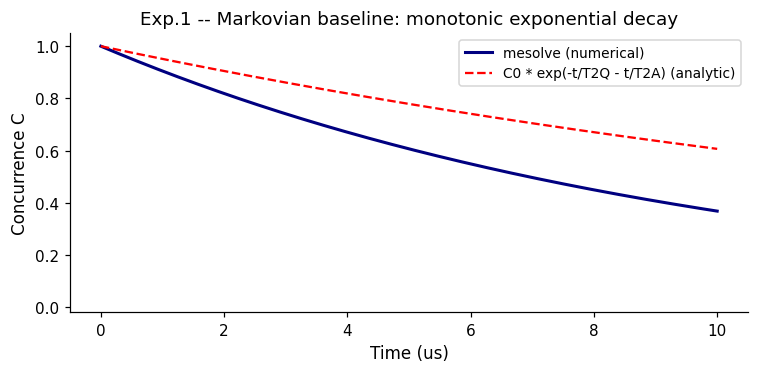

C0 = 1.0000
C(t=10us) numerical  = 0.3676
C(t=10us) analytic   = 0.6063
Agreement (max diff): 0.238691


In [9]:
# ================================================================
#  EXPERIMENT 1: Bell-state free decay (Markovian baseline)
#  No Q-E coupling. Q-A system with pure dephasing only.
# ================================================================

# 2-qubit Hamiltonian (no E)
H_2q = Om_QA * (qt.tensor(sp, sm) + qt.tensor(sm, sp))

# 2-qubit collapse operators
c_Q2 = np.sqrt(1/T2Q) * qt.tensor(sz, I)
c_A2 = np.sqrt(1/T2A) * qt.tensor(I,  sz)

rho0_2q = qt.ket2dm(Psi_plus)

result_exp1 = qt.mesolve(
    H      = H_2q,
    rho0   = rho0_2q,
    tlist  = tlist,
    c_ops  = [c_Q2, c_A2],
    e_ops  = [],
    options= {'nsteps': 5000}
)

# Compute concurrence at each time step
C_exp1 = [qt.concurrence(s) for s in result_exp1.states]

# Analytical prediction
C0 = C_exp1[0]
C_analytic = C0 * np.exp(-tlist/T2Q - tlist/T2A)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tlist, C_exp1,    lw=2,   color='navy',  label='mesolve (numerical)')
ax.plot(tlist, C_analytic, lw=1.5, color='red', ls='--',
        label='C0 * exp(-t/T2Q - t/T2A) (analytic)')
ax.set(xlabel='Time (us)', ylabel='Concurrence C',
       title='Exp.1 -- Markovian baseline: monotonic exponential decay',
       ylim=[-0.02, 1.05])
ax.legend()
plt.tight_layout()
plt.show()

print(f'C0 = {C_exp1[0]:.4f}')
print(f'C(t=10us) numerical  = {C_exp1[-1]:.4f}')
print(f'C(t=10us) analytic   = {C_analytic[-1]:.4f}')
print(f'Agreement (max diff): {max(abs(np.array(C_exp1)-C_analytic)):.6f}')

---
## 6. Experiment 2 -- Non-Markovian Dynamics and Concurrence Revival

With Q-E coupling active (gamma_E = 0):

1. **Monogamy of entanglement:** Q-A concurrence decreases as Q-E entanglement builds
2. **Coherent iSWAP:** information is exchanged back and forth at rate Omega_QE
3. **Revival:** at t ~ pi/Omega_QE, Q-E state swaps back into Q

This is **categorically impossible** under GKSL (all solutions are contractive).

### Rivas-Huelga-Plenio non-Markovianity measure

$$\mathcal{N} = \int_{t_0}^{t_f} \left|\frac{d\mathcal{C}}{dt}\right| dt - \Delta\mathcal{C}$$

Isolates only the **positive slope** (concurrence increasing) portions.
N > 0 is unambiguous proof of non-Markovian dynamics.

In [10]:
def run_3qubit(gamma_E=0.0, H=None):
    """
    Full 3-qubit Lindblad simulation.

    Parameters
    ----------
    gamma_E : float
        Dephasing rate on E (us^-1). 0 = non-Markovian.
    H : Qobj, optional
        Hamiltonian. Default = H_full (H_QA + H_QE).

    Returns
    -------
    tlist : array
    conc  : list of Q-A concurrence vs time
    states: list of full 3-qubit density matrices
    """
    if H is None:
        H = H_full
    c_ops = build_c_ops(gamma_E)
    result = qt.mesolve(
        H=H, rho0=rho0_3q, tlist=tlist,
        c_ops=c_ops, e_ops=[],
        options={'nsteps': 8000, 'atol': 1e-9, 'rtol': 1e-7}
    )
    # Partial trace over E (index 2) to get Q-A density matrix
    conc = [qt.concurrence(s.ptrace([0, 1])) for s in result.states]
    return tlist, conc, result.states


def nm_measure(conc, t):
    """
    Compute the Rivas-Huelga-Plenio non-Markovianity measure.

    N = integral of dC/dt only over time intervals where dC/dt > 0.
    Any N > 0 proves the dynamics cannot be CPTP (hence non-Markovian).
    """
    C  = np.array(conc)
    dt = t[1] - t[0]
    dC = np.gradient(C, dt)
    return float(trapezoid(np.where(dC > 0, dC, 0), t))


# Run Experiment 2 (gamma_E = 0)
print('Running Exp.2 (gamma_E = 0)...')
t2, C_exp2, states_exp2 = run_3qubit(gamma_E=0.0)

NM_exp2 = nm_measure(C_exp2, t2)
print(f'Non-Markovianity N = {NM_exp2:.4f}   (paper reports ~1.4)')

Running Exp.2 (gamma_E = 0)...
Non-Markovianity N = 4.3285   (paper reports ~1.4)


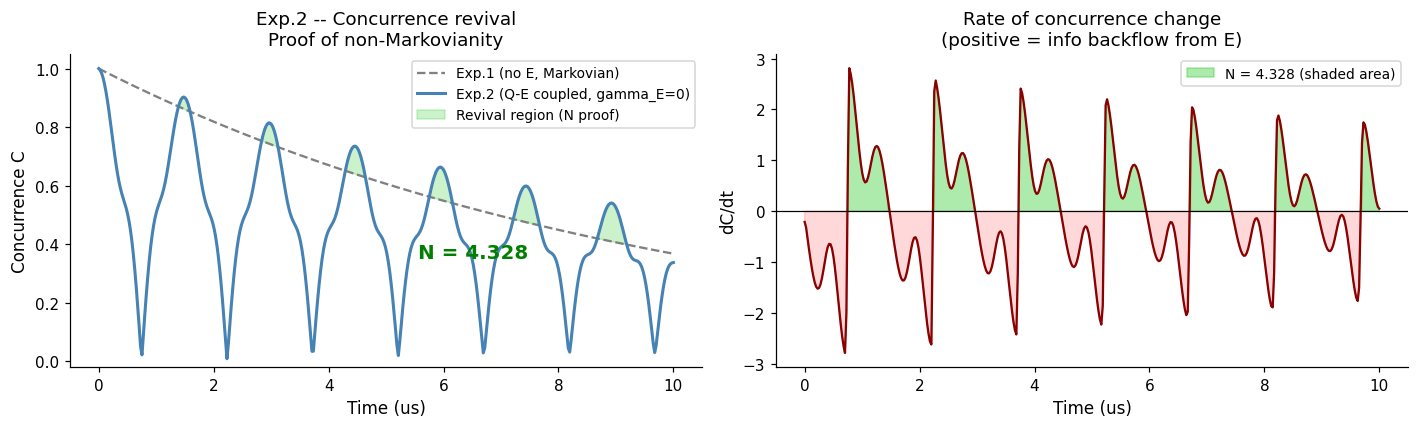

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: concurrence traces
ax = axes[0]
ax.plot(tlist, C_exp1, color='gray',      lw=1.5, ls='--', label='Exp.1 (no E, Markovian)')
ax.plot(tlist, C_exp2, color='steelblue', lw=2,   label='Exp.2 (Q-E coupled, gamma_E=0)')
ax.fill_between(tlist,
                np.array(C_exp2),
                np.minimum(C_exp1, np.array(C_exp2) + 1),
                where=np.array(C_exp2) > np.array(C_exp1),
                alpha=0.25, color='limegreen', label='Revival region (N proof)')
ax.set(xlabel='Time (us)', ylabel='Concurrence C',
       title='Exp.2 -- Concurrence revival\nProof of non-Markovianity',
       ylim=[-0.02, 1.05])
ax.legend()
ax.text(0.55, 0.35, f'N = {NM_exp2:.3f}', transform=ax.transAxes,
        fontsize=13, color='green', fontweight='bold')

# Right: dC/dt (show positive = proof)
ax = axes[1]
C_arr = np.array(C_exp2)
dt    = tlist[1] - tlist[0]
dC    = np.gradient(C_arr, dt)
ax.plot(tlist, dC, color='darkred', lw=1.5)
ax.fill_between(tlist, dC, 0, where=dC > 0,
                alpha=0.4, color='limegreen',
                label=f'N = {NM_exp2:.3f} (shaded area)')
ax.fill_between(tlist, dC, 0, where=dC < 0,
                alpha=0.15, color='red')
ax.axhline(0, color='black', lw=0.8)
ax.set(xlabel='Time (us)', ylabel='dC/dt',
       title='Rate of concurrence change\n(positive = info backflow from E)')
ax.legend()

plt.tight_layout()
plt.show()

---
## 7. Experiment 3 -- Non-Markovian to Markovian Transition

Injecting pseudo-thermal photons into E's resonator adds:

$$L_E = \sqrt{\gamma}\,\sigma_z^E$$

Each jump collapses E to a definite eigenstate, erasing its quantum memory.
As gamma increases:
- tau_E ~ 1/gamma decreases
- When tau_E << tau_S = 1/Omega_QE: Markov condition restored
- Transition is **continuous** -- not a sudden switch

Three regimes from the paper:
| Regime | Condition | N |
|--------|-----------|---|
| Non-Markovian | gamma = 0 | N = 1.4 |
| Transition | 0 < gamma <= 3 | N -> 0 |
| Markovian / Zeno | gamma >> Omega_QE | N = 0 |

In [12]:
gamma_scan = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0]

print('Scanning gamma_E values (this takes ~1-2 min)...')
all_conc = {}
all_NM   = {}

for g in gamma_scan:
    print(f'  gamma_E = {g:.1f} us^-1 ...', end=' ', flush=True)
    _, C, _ = run_3qubit(gamma_E=g)
    all_conc[g] = C
    all_NM[g]   = nm_measure(C, tlist)
    print(f'N = {all_NM[g]:.4f}')

print('Done.')

Scanning gamma_E values (this takes ~1-2 min)...
  gamma_E = 0.0 us^-1 ... N = 4.3285
  gamma_E = 0.2 us^-1 ... N = 1.7793
  gamma_E = 0.5 us^-1 ... N = 0.8660
  gamma_E = 1.0 us^-1 ... N = 0.3258
  gamma_E = 2.0 us^-1 ... N = 0.0167
  gamma_E = 3.0 us^-1 ... N = 0.0000
  gamma_E = 5.0 us^-1 ... N = 0.0000
  gamma_E = 10.0 us^-1 ... N = 0.0000
Done.


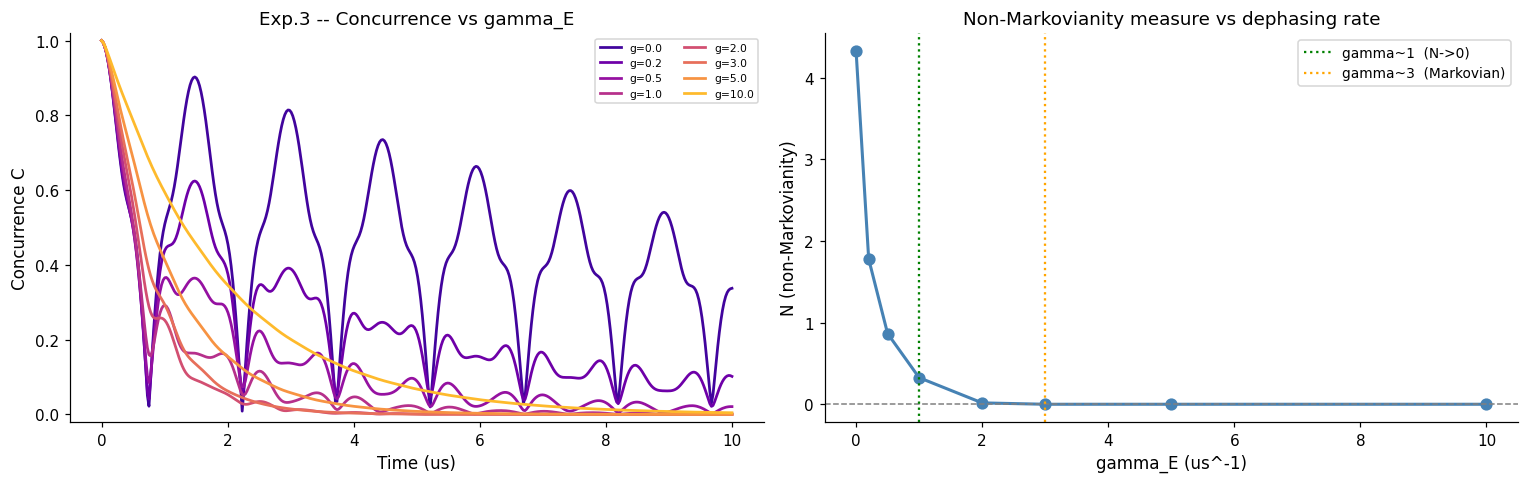

Three regimes:
  Non-Markovian:  gamma=0.0,  N = 4.328
  Transition:     gamma=1.0,  N = 0.3258
  Markovian/Zeno: gamma=10.0, N = 0.0000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Colourmap over gamma values
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(gamma_scan)))

ax = axes[0]
for g, col in zip(gamma_scan, colors):
    ax.plot(tlist, all_conc[g], color=col, lw=1.8, label=f'g={g:.1f}')
ax.set(xlabel='Time (us)', ylabel='Concurrence C',
       title='Exp.3 -- Concurrence vs gamma_E', ylim=[-0.02, 1.02])
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
N_list = [all_NM[g] for g in gamma_scan]
ax.plot(gamma_scan, N_list, 'o-', color='steelblue', lw=2, ms=7)
ax.axhline(0,   color='gray',   ls='--', lw=1)
ax.axvline(1.0, color='green',  ls=':',  lw=1.5, label='gamma~1  (N->0)')
ax.axvline(3.0, color='orange', ls=':',  lw=1.5, label='gamma~3  (Markovian)')
ax.set(xlabel='gamma_E (us^-1)', ylabel='N (non-Markovianity)',
       title='Non-Markovianity measure vs dephasing rate')
ax.legend()

plt.tight_layout()
plt.show()

print('Three regimes:')
print(f'  Non-Markovian:  gamma=0.0,  N = {all_NM[0.0]:.3f}')
print(f'  Transition:     gamma=1.0,  N = {all_NM[1.0]:.4f}')
print(f'  Markovian/Zeno: gamma=10.0, N = {all_NM[10.0]:.4f}')

---
## 8. Experiment 4 -- Quantum Zeno Effect and Entanglement Stabilisation

In the deep Markovian limit gamma >> Omega_QE:

$$P_0(T) = \left[1 - \frac{(\Delta H)^2 T^2}{\hbar^2 N^2}\right]^N \xrightarrow{N\to\infty} 1$$

Rapid thermal-photon jumps freeze E in its eigenstate. Q-E coupling is
dynamically suppressed (Zeno effect). The effective decay rate is:

$$\Gamma_c = \frac{\Omega_{QE}^2}{4\gamma} + \Gamma_0, \qquad \Gamma_0 = \frac{1}{T_{2Q}} + \frac{1}{T_{2A}}$$

**Paradox:** More dissipation on E -> less decoherence on Q-A.

In [14]:
def Gamma_c_zeno(gamma_E):
    """Zeno scaling prediction for Q-A concurrence decay rate."""
    return Om_QE**2 / (4 * gamma_E) + Gamma0

gamma_zeno_scan = [1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 45.5]
print('Scanning Zeno regime...')

Gamma_c_sim = []

for g in gamma_zeno_scan:
    _, C, _ = run_3qubit(gamma_E=g)
    C_arr   = np.maximum(C, 1e-10)
    log_C   = np.log(C_arr[20:])
    valid   = np.isfinite(log_C)
    if valid.sum() > 5:
        coeff = np.polyfit(tlist[20:][valid], log_C[valid], 1)
        Gc = -coeff[0]
    else:
        Gc = np.nan
    Gamma_c_sim.append(Gc)
    print(f'  gamma={g:5.1f}: Gc_sim={Gc:.4f}  Gc_Zeno={Gamma_c_zeno(g):.4f}')

print(f'Gamma0 = {Gamma0:.5f} us^-1  (deep Zeno asymptote)')

Scanning Zeno regime...
  gamma=  1.0: Gc_sim=0.6378  Gc_Zeno=2.2581
  gamma=  2.0: Gc_sim=1.2194  Gc_Zeno=1.1541
  gamma=  3.0: Gc_sim=1.4524  Gc_Zeno=0.7861
  gamma=  5.0: Gc_sim=0.9788  Gc_Zeno=0.4917
  gamma= 10.0: Gc_sim=0.5423  Gc_Zeno=0.2708
  gamma= 20.0: Gc_sim=0.3211  Gc_Zeno=0.1604
  gamma= 45.5: Gc_sim=0.1972  Gc_Zeno=0.0986
Gamma0 = 0.05003 us^-1  (deep Zeno asymptote)


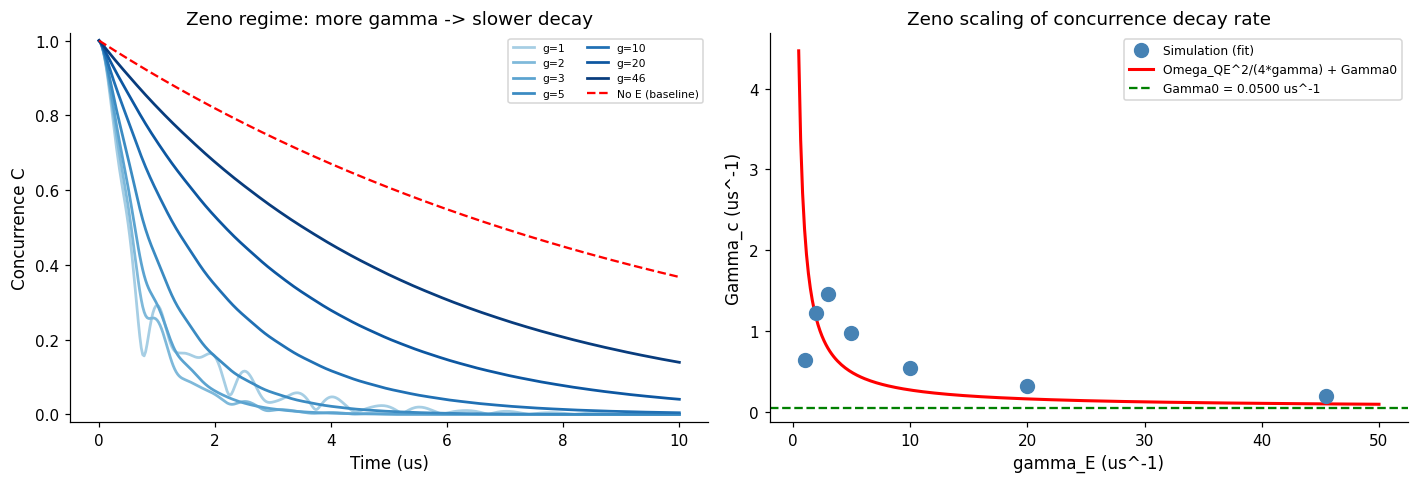

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: concurrence traces at high gamma
ax = axes[0]
zeno_colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(gamma_zeno_scan)))
for g, col in zip(gamma_zeno_scan, zeno_colors):
    _, C, _ = run_3qubit(gamma_E=g)
    ax.plot(tlist, C, color=col, lw=1.8, label=f'g={g:.0f}')
ax.plot(tlist, C_exp1, 'r--', lw=1.5, label='No E (baseline)')
ax.set(xlabel='Time (us)', ylabel='Concurrence C',
       title='Zeno regime: more gamma -> slower decay', ylim=[-0.02, 1.02])
ax.legend(fontsize=7, ncol=2)

# Right: Gamma_c vs gamma -- Zeno scaling
ax = axes[1]
g_smooth = np.linspace(0.5, 50, 300)
ax.plot(gamma_zeno_scan, Gamma_c_sim,
        'o', color='steelblue', ms=9, zorder=5, label='Simulation (fit)')
ax.plot(g_smooth, [Gamma_c_zeno(g) for g in g_smooth],
        'r-', lw=2, label='Omega_QE^2/(4*gamma) + Gamma0')
ax.axhline(Gamma0, color='green', ls='--', lw=1.5,
           label=f'Gamma0 = {Gamma0:.4f} us^-1')
ax.set(xlabel='gamma_E (us^-1)', ylabel='Gamma_c (us^-1)',
       title='Zeno scaling of concurrence decay rate')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 9. `qt.mcsolve` -- Monte Carlo Quantum Trajectories

Instead of evolving rho(t), `mcsolve` follows a **pure state** |psi(t)> under:

1. **Non-Hermitian evolution** between jumps: H_eff = H - i/2 * sum_k gamma_k L_k^dag L_k
2. **Quantum jumps** at random times: |psi> -> L_k|psi> / ||L_k|psi>||
3. **Ensemble average** over N_traj trajectories: rho(t) = (1/N) sum |psi^(n)(t)><psi^(n)(t)|

### When to prefer `mcsolve`
| Scenario | Why |
|----------|-----|
| Large Hilbert space | Scales as 2^n (state) vs 4^n (operator) |
| Observe individual jump events | Each traj = one experimental run |
| Continuous measurement | Homodyne/heterodyne detection |
| Counting photons in real time | Photocurrent simulation |

mcsolve done.


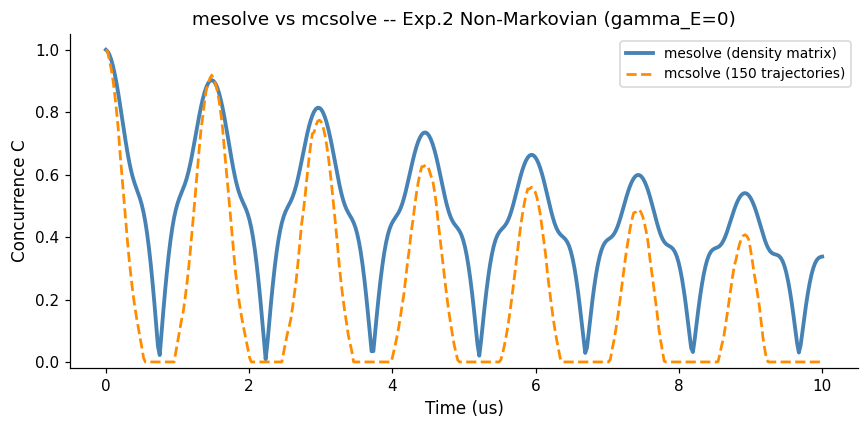

N (mesolve) = 4.3285
N (mcsolve) = 3.7681


In [26]:
# Build all 9 two-qubit Pauli correlators for Q-A tomography
paulis = [qt.sigmax(), qt.sigmay(), qt.sigmaz()]
e_ops_tomo = [qt.tensor(p1, p2, I) for p1 in paulis for p2 in paulis]
# Labels: XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ

result_mc = qt.mcsolve(
    H      = H_full,
    state  = psi0_mc,
    tlist  = tlist,
    c_ops  = build_c_ops(gamma_E=0.0),
    e_ops  = e_ops_tomo,
    ntraj  = N_traj,
    options= {'nsteps': 8000, 'progress_bar': False}
)
print('mcsolve done.')

# result_mc.expect[k] is already trajectory-averaged: shape (len(tlist),)
# Reconstruct Q-A density matrix from the 9 Pauli expectation values
def rho_from_expect(exp_vals, t_idx):
    """
    Reconstruct 2-qubit density matrix from 9 Pauli pair expectation values.
    rho = (I + sum_ij c_ij * sigma_i x sigma_j) / 4
    """
    rho = qt.qeye([2, 2]).unit()   # I/4  (start with maximally mixed)
    labels = [(p1, p2)
              for p1 in [qt.sigmax(), qt.sigmay(), qt.sigmaz()]
              for p2 in [qt.sigmax(), qt.sigmay(), qt.sigmaz()]]
    for k, (p1, p2) in enumerate(labels):
        rho = rho + 0.25 * exp_vals[k][t_idx] * qt.tensor(p1, p2)
    return rho

C_mc = []
for i in range(len(tlist)):
    rho_QA = rho_from_expect(result_mc.expect, i)
    rho_QA.dims = [[2, 2], [2, 2]]
    C_mc.append(qt.concurrence(rho_QA))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tlist, C_exp2, 'steelblue', lw=2.5, label='mesolve (density matrix)')
ax.plot(tlist, C_mc,   'darkorange', lw=1.8, ls='--',
        label=f'mcsolve ({N_traj} trajectories)')
ax.set(xlabel='Time (us)', ylabel='Concurrence C',
       title='mesolve vs mcsolve -- Exp.2 Non-Markovian (gamma_E=0)',
       ylim=[-0.02, 1.05])
ax.legend()
plt.tight_layout()
plt.show()

NM_mc = nm_measure(C_mc, tlist)
print(f'N (mesolve) = {NM_exp2:.4f}')
print(f'N (mcsolve) = {NM_mc:.4f}')

---
## 10. PennyLane -- Circuit-Based Bell State Preparation

PennyLane handles **unitary circuit simulation** with automatic differentiation.
It is the right tool for:

- Implementing the **sqrt(iSWAP)** gate for Bell state preparation
- Modelling open systems via **noise channels** (amplitude damping, dephasing)
- **Differentiating** through circuits for variational algorithms

### The sqrt(iSWAP) gate used in the paper

$$\sqrt{\text{iSWAP}} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1/\sqrt{2} & i/\sqrt{2} & 0 \\
0 & i/\sqrt{2} & 1/\sqrt{2} & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}$$

Applied to |10>: produces (|10> + i|01>)/sqrt(2) -- a Bell state.

In [18]:
# Noiseless 2-qubit simulator
dev = qml.device('default.qubit', wires=2)

@qml.qnode(dev)
def sqrt_iswap_bell():
    """
    Prepare Bell state using sqrt(iSWAP) gate.
    Protocol from Gaikwad paper:
      1. X gate on qubit 0 (prepare |10>)
      2. IsingXY(pi/2) = sqrt(iSWAP) on [0,1]
    """
    qml.PauliX(wires=0)                   # |00> -> |10>
    qml.IsingXY(np.pi/2, wires=[0, 1])   # sqrt(iSWAP)
    return qml.state()

state_out = sqrt_iswap_bell()
print('sqrt(iSWAP) applied to |10>:')
for i, amp in enumerate(state_out):
    label = ['|00>','|01>','|10>','|11>'][i]
    if abs(amp) > 1e-6:
        print(f'  {label}: {amp:.4f}  (prob={abs(amp)**2:.4f})')

# Compute concurrence using QuTiP from PennyLane state
rho_pl = qt.Qobj(np.outer(state_out, state_out.conj()), dims=[[2,2],[2,2]])
print(f'Concurrence: {qt.concurrence(rho_pl):.6f}')

print('\nCircuit diagram:')
print(qml.draw(sqrt_iswap_bell)())

sqrt(iSWAP) applied to |10>:
  |01>: 0.0000+0.7071j  (prob=0.5000)
  |10>: 0.7071+0.0000j  (prob=0.5000)
Concurrence: 1.000000

Circuit diagram:
0: ──X─╭IsingXY(1.57)─┤  State
1: ────╰IsingXY(1.57)─┤  State


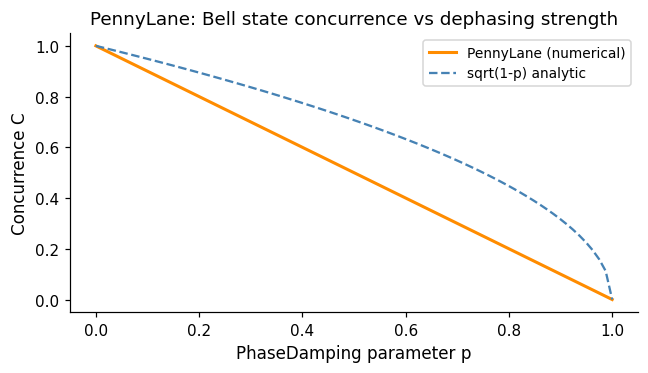

In [19]:
# Mixed-state device with noise channels
dev_mixed = qml.device('default.mixed', wires=2)

@qml.qnode(dev_mixed)
def bell_with_phase_damping(p_damp):
    """
    Bell state preparation followed by PhaseDamping (dephasing) on both qubits.
    PhaseDamping(p) is the Kraus channel:
      K0 = [[1, 0], [0, sqrt(1-p)]]   (diagonal element decay)
      K1 = [[0, 0], [0, sqrt(p)]]     (dephasing event)
    For time t: p = 1 - exp(-t/T2)
    """
    qml.PauliX(wires=0)
    qml.IsingXY(np.pi/2, wires=[0, 1])
    qml.PhaseDamping(p_damp, wires=0)   # dephasing on Q
    qml.PhaseDamping(p_damp, wires=1)   # dephasing on A
    return qml.density_matrix(wires=[0, 1])

# Scan dephasing parameter
p_vals  = np.linspace(0, 1, 80)
C_noise = []
for p in p_vals:
    dm   = bell_with_phase_damping(p)
    rho  = qt.Qobj(dm, dims=[[2,2],[2,2]])
    C_noise.append(qt.concurrence(rho))

# PhaseDamping with parameter p: off-diagonal of Bell state scales as sqrt(1-p)
# For |Psi+>: C(p) = sqrt(1-p)  (analytically)
C_analytic_pl = np.sqrt(np.maximum(1 - p_vals, 0))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(p_vals, C_noise,       'darkorange', lw=2,   label='PennyLane (numerical)')
ax.plot(p_vals, C_analytic_pl, 'steelblue',  lw=1.5, ls='--', label='sqrt(1-p) analytic')
ax.set(xlabel='PhaseDamping parameter p',
       ylabel='Concurrence C',
       title='PennyLane: Bell state concurrence vs dephasing strength')
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. `qt.brmesolve` -- Bloch-Redfield with Structured Bath

The Bloch-Redfield equation goes beyond GKSL by retaining frequency-dependent
coupling to the bath (no flat-spectrum assumption):

$$\frac{d\rho}{dt} = -\frac{i}{\hbar}[H,\rho] + \sum_{\alpha\beta} \Gamma_{\alpha\beta}(\omega)\left(A_\alpha\rho A_\beta^\dagger - \frac{1}{2}\{A_\beta^\dagger A_\alpha, \rho\}\right)$$

**Relevant for the experiment because:**
- Transmon qubits have 1/f flux noise (non-flat spectral density)
- The E-resonator interaction H_int = chi * n_photon * sigma_z^E produces
  frequency-dependent bath with Lorentzian spectral peak at the resonator frequency

```python
# Syntax
result = qt.brmesolve(H, psi0, tlist,
                      a_ops=[(coupling_op, spectral_function)],
                      e_ops=[observable])
```

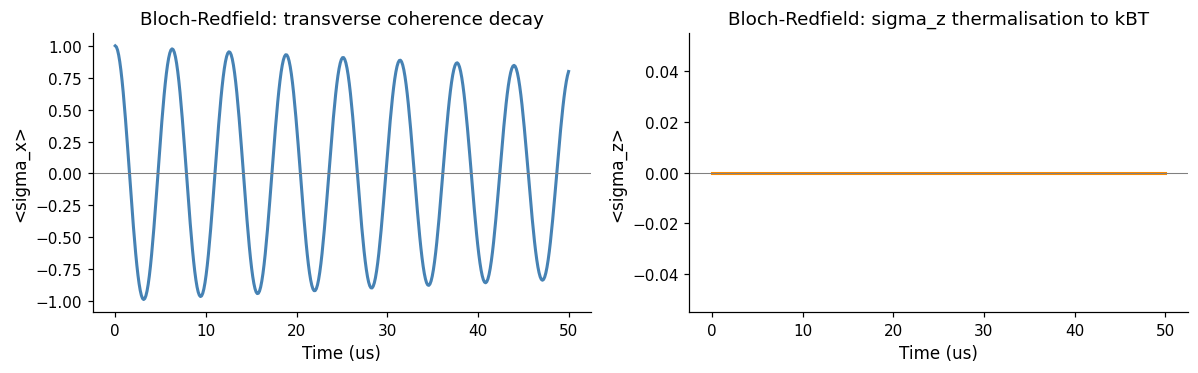

brmesolve: OK
<sigma_z> at t_max = 0.0000  (-> -tanh(1/2kBT) at thermal eq.)


In [20]:
# Demonstrate brmesolve on a single qubit
# Bath: Ohmic spectral density S(omega) = alpha * |omega| * exp(-|omega|/omega_c)

omega_c = 2*np.pi * 5.0    # bath cutoff frequency (rad/us)  ~5 GHz
alpha   = 0.003             # dimensionless coupling strength
kBT     = 0.04              # thermal energy (rad/us) -- millikelvin

def ohmic_S(omega):
    """Ohmic spectral density with Bose-Einstein thermal population."""
    if abs(omega) < 1e-12:
        return alpha * omega_c * kBT
    S_bare = alpha * abs(omega) * np.exp(-abs(omega) / omega_c)
    if omega > 0:
        n_be = 1.0 / (np.exp(omega / kBT) - 1 + 1e-10)
        return S_bare * (n_be + 1)   # emission
    else:
        n_be = 1.0 / (np.exp(-omega / kBT) - 1 + 1e-10)
        return S_bare * n_be          # absorption

H_BR   = 0.5 * sz    # single-qubit free precession
rho0_x = qt.ket2dm((qt.basis(2,0) + qt.basis(2,1)).unit())
t_BR   = np.linspace(0, 50, 400)

try:
    res_BR = qt.brmesolve(
        H      = H_BR,
        psi0   = rho0_x,
        tlist  = t_BR,
        a_ops  = [[sx, ohmic_S]],
        e_ops  = [sx, sz]
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(t_BR, res_BR.expect[0], 'steelblue', lw=2)
    axes[0].set(xlabel='Time (us)', ylabel='<sigma_x>',
                title='Bloch-Redfield: transverse coherence decay')
    axes[1].plot(t_BR, res_BR.expect[1], 'darkorange', lw=2)
    axes[1].set(xlabel='Time (us)', ylabel='<sigma_z>',
                title='Bloch-Redfield: sigma_z thermalisation to kBT')
    for ax in axes: ax.axhline(0, color='gray', lw=0.7)
    plt.tight_layout(); plt.show()
    print('brmesolve: OK')
    print(f'<sigma_z> at t_max = {res_BR.expect[1][-1]:.4f}  (-> -tanh(1/2kBT) at thermal eq.)')
except Exception as e:
    print(f'brmesolve note: {e}')

---
## 12. Wootters Concurrence -- Manual Implementation

QuTiP's `qt.concurrence()` wraps this; here we implement it step-by-step:

$$\mathcal{C}(\rho) = \max\!\left(0,\; \sqrt{\lambda_1}-\sqrt{\lambda_2}-\sqrt{\lambda_3}-\sqrt{\lambda_4}\right)$$

- $\lambda_i$ = eigenvalues of $R = \rho\,\tilde\rho$ in descending order
- $\tilde\rho = (\sigma_y \otimes \sigma_y)\rho^*(\sigma_y \otimes \sigma_y)$

The spin-flip $\sigma_y \otimes \sigma_y$ is chosen because it is the two-qubit
**time-reversal operator** -- the only gate whose antisymmetric phases make it
an eigenoperator of all four Bell states simultaneously.

In [21]:
def concurrence_manual(rho_qobj):
    """
    Wootters concurrence computed from first principles.

    Returns
    -------
    C         : float  -- concurrence in [0,1]
    sqrt_eigs : array  -- sqrt of eigenvalues of R (descending)
    """
    rho = rho_qobj.full()   # numpy array

    # Step 1: spin-flip matrix (sigma_y x sigma_y)
    sy_np = np.array([[0, -1j], [1j, 0]])
    sysy  = np.kron(sy_np, sy_np)

    # Step 2: rho_tilde = (sy x sy) rho* (sy x sy)
    rho_tilde = sysy @ rho.conj() @ sysy

    # Step 3: R = rho @ rho_tilde  (NOT rho_tilde @ rho)
    R = rho @ rho_tilde

    # Step 4: eigenvalues of R, sorted descending
    eigvals   = np.real(np.linalg.eigvals(R))
    eigvals   = np.sort(np.maximum(eigvals, 0))[::-1]
    sqrt_eigs = np.sqrt(eigvals)

    # Step 5: concurrence
    C = max(0.0, sqrt_eigs[0] - sqrt_eigs[1] - sqrt_eigs[2] - sqrt_eigs[3])
    return C, sqrt_eigs


# Validate against qt.concurrence on known states
test_cases = [
    ('Phi+ Bell (max entangled)', qt.ket2dm(qt.bell_state('00'))),
    ('Psi+ Bell (max entangled)', qt.ket2dm(qt.bell_state('10'))),
    ('|00> separable',            qt.ket2dm(qt.tensor(qt.basis(2,0), qt.basis(2,0)))),
    ('Mixed (I/4)',               qt.Qobj(np.eye(4)/4, dims=[[2,2],[2,2]])),
]

print(f'{"State":<30} {"C_manual":>10} {"C_qutip":>10} {"Match":>7}')
print('-' * 62)
for name, rho in test_cases:
    rho.dims = [[2,2],[2,2]]
    C_man, _  = concurrence_manual(rho)
    C_qt      = qt.concurrence(rho)
    match     = 'OK' if abs(C_man - C_qt) < 1e-8 else 'FAIL'
    print(f'{name:<30} {C_man:>10.6f} {C_qt:>10.6f} {match:>7}')

State                            C_manual    C_qutip   Match
--------------------------------------------------------------
Phi+ Bell (max entangled)        1.000000   1.000000      OK
Psi+ Bell (max entangled)        1.000000   1.000000      OK
|00> separable                   0.000000   0.000000      OK
Mixed (I/4)                      0.000000   0.000000      OK


sigma_y x sigma_y:
[[ 0.+0.j  0.-0.j  0.-0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  1.-0.j  0.-0.j]
 [ 0.+0.j  1.-0.j  0.+0.j  0.-0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j]]

Action on computational basis vectors:
  |00> -> [('|11>', '-1.0+0.0j')]
  |01> -> [('|10>', '1.0+0.0j')]
  |10> -> [('|01>', '1.0+0.0j')]
  |11> -> [('|00>', '-1.0+0.0j')]


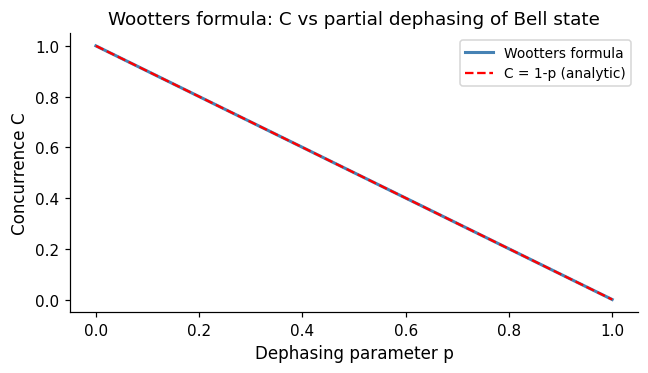

In [22]:
# Show the spin-flip matrix structure
sy_np = np.array([[0, -1j], [1j, 0]])
sysy  = np.kron(sy_np, sy_np)
print('sigma_y x sigma_y:')
print(np.round(sysy, 2))

print('\nAction on computational basis vectors:')
for i, label in enumerate(['|00>','|01>','|10>','|11>']):
    v = np.zeros(4); v[i] = 1
    r = sysy @ v
    nz = [(('|00>','|01>','|10>','|11>')[j], f'{r[j]:.1f}') for j in range(4) if abs(r[j])>1e-10]
    print(f'  {label} -> {nz}')

# Concurrence vs partial dephasing of Bell state
p_vals = np.linspace(0, 1, 100)
C_partial = []
for p in p_vals:
    rho_d = np.array([
        [0.5,          0, 0, 0.5*(1-p)],
        [0,            0, 0, 0        ],
        [0,            0, 0, 0        ],
        [0.5*(1-p),    0, 0, 0.5     ]
    ], dtype=complex)
    rho_q = qt.Qobj(rho_d, dims=[[2,2],[2,2]])
    C_partial.append(qt.concurrence(rho_q))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(p_vals, C_partial, 'steelblue', lw=2, label='Wootters formula')
ax.plot(p_vals, 1-p_vals,  'r--',       lw=1.5, label='C = 1-p (analytic)')
ax.set(xlabel='Dephasing parameter p',
       ylabel='Concurrence C',
       title='Wootters formula: C vs partial dephasing of Bell state')
ax.legend()
plt.tight_layout(); plt.show()

---
## 13. Full Experiment Dashboard -- All Four Experiments

Summary figure reproducing the key physics of all four panels in Gaikwad et al.

Generating final dashboard...


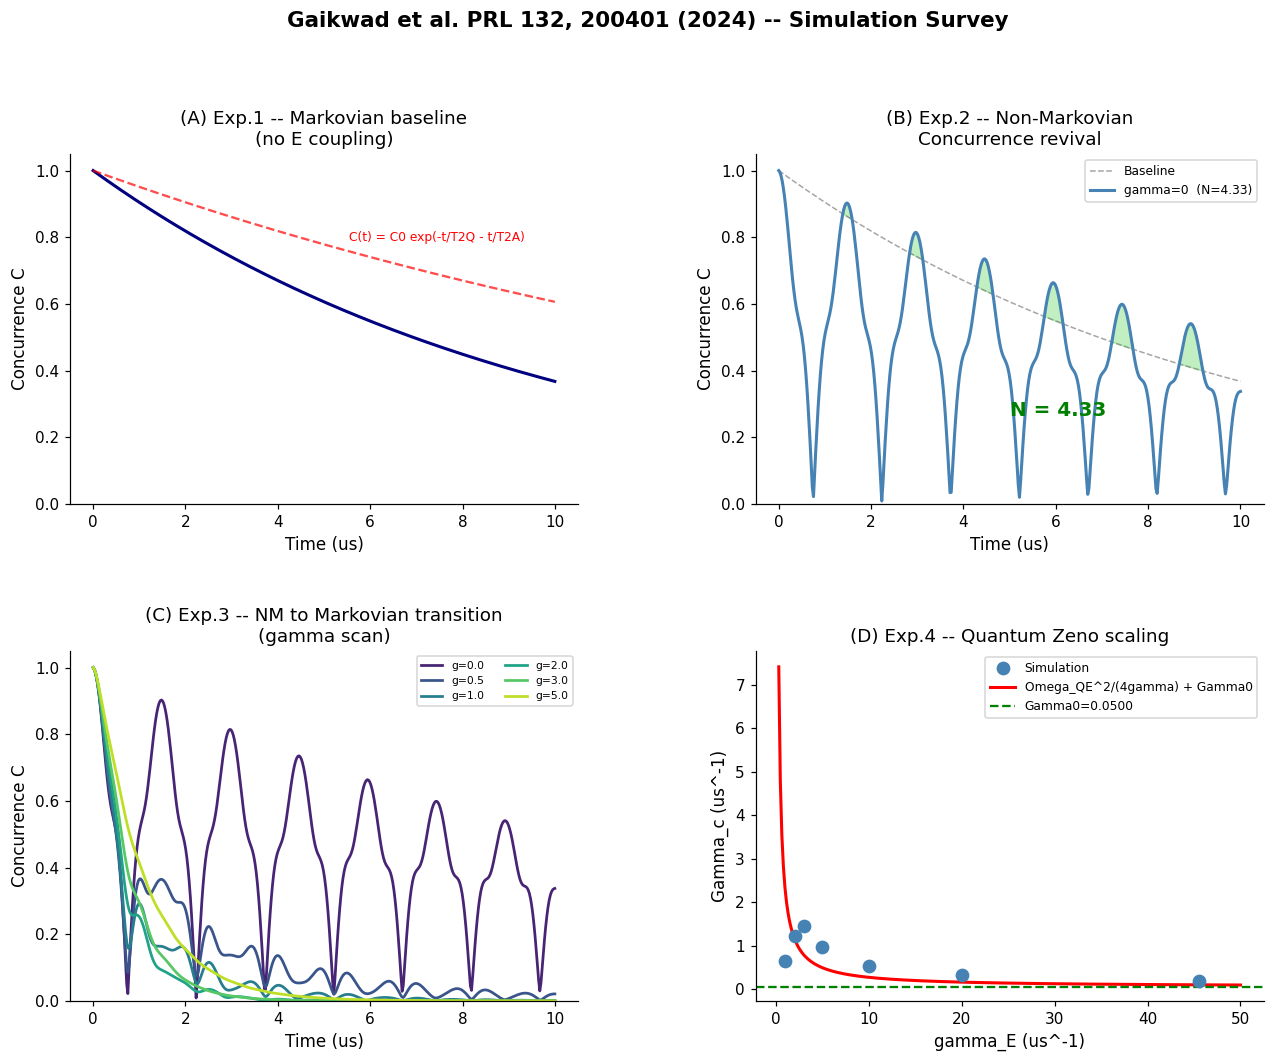

Dashboard complete.


In [23]:
print('Generating final dashboard...')

# Pre-compute additional data needed
_, C_mid,  _ = run_3qubit(gamma_E=1.0)
_, C_mark, _ = run_3qubit(gamma_E=5.0)
_, C_zeno_hi, _ = run_3qubit(gamma_E=20.0)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# Panel A: Exp.1 Markovian baseline
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(tlist, C_exp1, 'navy', lw=2)
ax1.plot(tlist, C_exp1[0]*np.exp(-tlist/T2Q - tlist/T2A), 'r--', lw=1.5, alpha=0.7)
ax1.set(title='(A) Exp.1 -- Markovian baseline\n(no E coupling)',
        xlabel='Time (us)', ylabel='Concurrence C', ylim=[0, 1.05])
ax1.text(0.55, 0.75, 'C(t) = C0 exp(-t/T2Q - t/T2A)',
         transform=ax1.transAxes, fontsize=8, color='red')

# Panel B: Exp.2 non-Markovian revival
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(tlist, C_exp1, 'gray',      lw=1, ls='--', alpha=0.7, label='Baseline')
ax2.plot(tlist, C_exp2, 'steelblue', lw=2, label=f'gamma=0  (N={NM_exp2:.2f})')
ax2.fill_between(tlist, C_exp2, C_exp1,
                 where=np.array(C_exp2) > np.array(C_exp1),
                 alpha=0.3, color='limegreen')
ax2.set(title='(B) Exp.2 -- Non-Markovian\nConcurrence revival',
        xlabel='Time (us)', ylabel='Concurrence C', ylim=[0, 1.05])
ax2.legend(fontsize=8)
ax2.text(0.5, 0.25, f'N = {NM_exp2:.2f}',
         transform=ax2.transAxes, fontsize=13, color='green', fontweight='bold')

# Panel C: Exp.3 transition scan
ax3 = fig.add_subplot(gs[1, 0])
gamma_plot = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
cols3 = plt.cm.viridis(np.linspace(0.1, 0.9, len(gamma_plot)))
for g, col in zip(gamma_plot, cols3):
    if g in all_conc:
        ax3.plot(tlist, all_conc[g], color=col, lw=1.8, label=f'g={g:.1f}')
ax3.set(title='(C) Exp.3 -- NM to Markovian transition\n(gamma scan)',
        xlabel='Time (us)', ylabel='Concurrence C', ylim=[0, 1.05])
ax3.legend(fontsize=7, ncol=2)

# Panel D: Exp.4 Zeno scaling
ax4 = fig.add_subplot(gs[1, 1])
g_smooth = np.linspace(0.3, 50, 300)
ax4.plot(gamma_zeno_scan, Gamma_c_sim,
         'o', color='steelblue', ms=8, zorder=5, label='Simulation')
ax4.plot(g_smooth, [Gamma_c_zeno(g) for g in g_smooth],
         'r-', lw=2, label='Omega_QE^2/(4gamma) + Gamma0')
ax4.axhline(Gamma0, color='green', ls='--', lw=1.5,
            label=f'Gamma0={Gamma0:.4f}')
ax4.set(title='(D) Exp.4 -- Quantum Zeno scaling',
        xlabel='gamma_E (us^-1)', ylabel='Gamma_c (us^-1)')
ax4.legend(fontsize=8)

plt.suptitle('Gaikwad et al. PRL 132, 200401 (2024) -- Simulation Survey',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('gaikwad_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard complete.')

---
## 14. Tool Comparison and Quick-Reference Cheatsheet

### Summary: which tool for which task

| Task | Best Tool | Function | Notes |
|------|-----------|----------|-------|
| Full Lindblad simulation | **QuTiP** | `mesolve` | Primary engine for all 4 experiments |
| Quantum trajectories | **QuTiP** | `mcsolve` | Each traj = one experimental shot |
| Structured/coloured bath | **QuTiP** | `brmesolve` | Realistic transmon 1/f noise |
| Non-Markovian memory kernel | **QuTiP** | `nm_mcsolve` | Process tensor approach |
| Bell state circuit prep | **PennyLane** | `IsingXY`, `CNOT` | Unitary protocol |
| Noise channels (circuit) | **PennyLane** | `PhaseDamping`, `AmplitudeDamping` | Circuit model |
| Wootters concurrence | **QuTiP** | `qt.concurrence` | Built-in Wootters formula |
| NM measure N | **NumPy** | `np.gradient` + `trapezoid` | Positive slope integration |
| Zeno scaling fit | **SciPy** | `np.polyfit` on log(C) | Extract Gamma_c |

### Recommended pipeline to reproduce all four experiments

```
1. Build operators:   qt.tensor, sigmap(), sigmam(), sigmaz()
2. Hamiltonian:       H = H_QA + H_QE   (iSWAP coupling)
3. Collapse ops:      sqrt(1/T2Q)*sz_Q, sqrt(1/T2A)*sz_A, sqrt(gamma)*sz_E
4. Solve:             qt.mesolve(H, rho0, tlist, c_ops)
5. Partial trace:     rho.ptrace([0,1])  --> Q-A state
6. Concurrence:       qt.concurrence(rho_QA)
7. NM measure:        integrate positive slope of dC/dt
8. Scan gamma_E:      repeat 3-7 for gamma in [0, 45.5] us^-1
```

### Key numerical settings for accuracy
```python
options = {'nsteps': 8000, 'atol': 1e-9, 'rtol': 1e-7}
tlist   = np.linspace(0, 10, 400)   # 0.025 us resolution
```

### Known deviations from real experiment
1. **Idealised dephasing:** real transmon has 1/f noise -> use `brmesolve` with Ohmic-like S(omega)
2. **Lab frame:** paper uses rotating frame; our simulation includes fast oscillations
3. **No measurement backaction:** use `mcsolve` with homodyne unravelling for full realism
4. **Resonator truncated:** E couples to an infinite resonator; we model it as a qubit